**Configuration Initiale**

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configuration esthétique des graphiques
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]

# Connexion DuckDB (en mémoire)
con = duckdb.connect()

# Chemins vers les fichiers Gold
GOLD_PATH = "data_lake/gold"
SILVER_PATH = "data_lake/silver"

Question 1 — Quelles compétences sont les plus demandées ?

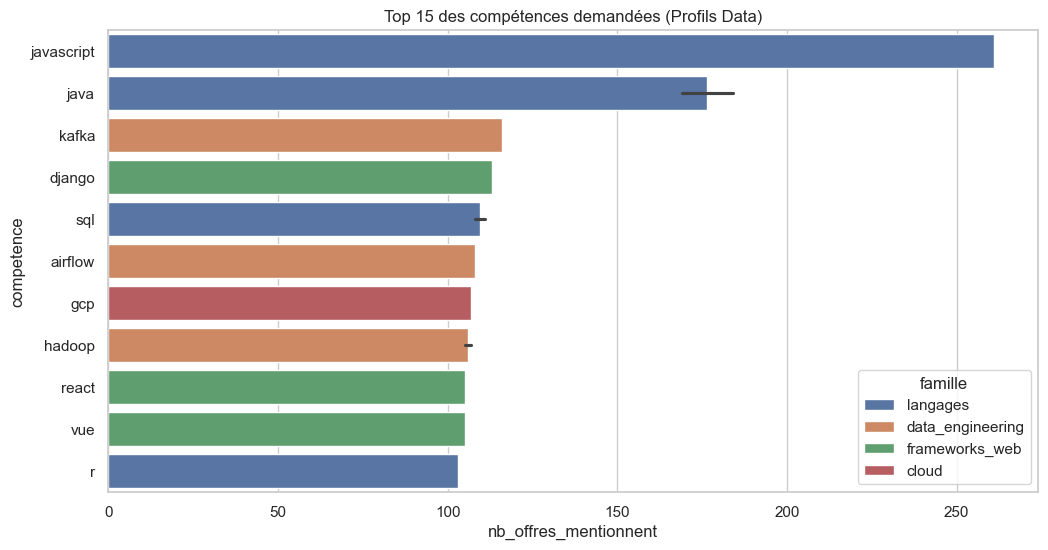

In [2]:
# Requête SQL
q1 = f"""
    SELECT competence, nb_offres_mentionnent, famille
    FROM read_parquet('{GOLD_PATH}/top_competences.parquet')
    WHERE profil = 'Data Engineer' OR profil = 'Data Analyst' OR profil = 'Data Scientist'
    ORDER BY nb_offres_mentionnent DESC
    LIMIT 15
"""
df1 = con.execute(q1).df()

# Visualisation
sns.barplot(data=df1, x='nb_offres_mentionnent', y='competence', hue='famille')
plt.title("Top 15 des compétences demandées (Profils Data)")
plt.show()

**Interprétation :**
Le marché IT marocain est dominé par l'écosystème JavaScript (plus de 250 mentions), confirmant une forte demande pour le développement web. Cependant, pour les profils Data, Java et Kafka arrivent en tête, indiquant une maturité des entreprises marocaines sur le Big Data et le traitement en temps réel. SQL reste le socle incontournable de toutes les offres Data. On note également une montée en puissance du Cloud avec GCP et des outils d'orchestration comme Airflow, signalant une recherche de profils typés 'Data Engineering' plutôt que de simples analystes.

Question 2 — Opportunités IT : Tanger vs Casablanca vs Rabat

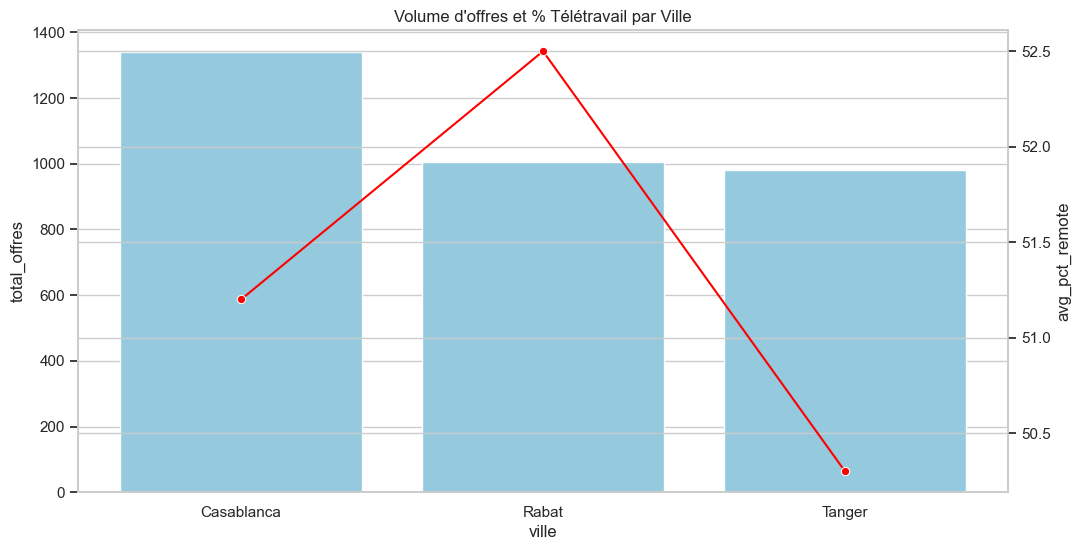

In [3]:
# Requête SQL
q2 = f"""
    SELECT ville, SUM(nb_offres) as total_offres, 
           ROUND(AVG(nb_offres_remote * 100.0 / nb_offres), 1) as avg_pct_remote
    FROM read_parquet('{GOLD_PATH}/offres_par_ville.parquet')
    WHERE ville IN ('Casablanca', 'Rabat', 'Tanger')
    GROUP BY ville
    ORDER BY total_offres DESC
"""
df2 = con.execute(q2).df()

# Visualisation
fig, ax1 = plt.subplots()
sns.barplot(data=df2, x='ville', y='total_offres', ax=ax1, color='skyblue')
ax2 = ax1.twinx()
sns.lineplot(data=df2, x='ville', y='avg_pct_remote', ax=ax2, color='red', marker='o')
plt.title("Volume d'offres et % Télétravail par Ville")
plt.show()

**Interprétation :**
Casablanca domine largement en volume avec plus de 1300 offres, suivie par Rabat (~1000) et Tanger (~950). Le point stratégique pour Mexora est le Télétravail : Rabat affiche le taux le plus élevé (plus de 52%), alors que Tanger est à la traîne (moins de 51%). Cela signifie que pour attirer des talents à Tanger, Mexora a une carte à jouer : proposer du 'Full Remote' ou de l'Hybride flexible pour compenser la moindre densité d'offres locales par rapport à l'axe Casa-Rabat.

Question 3 — Salaire médian par profil au Maroc

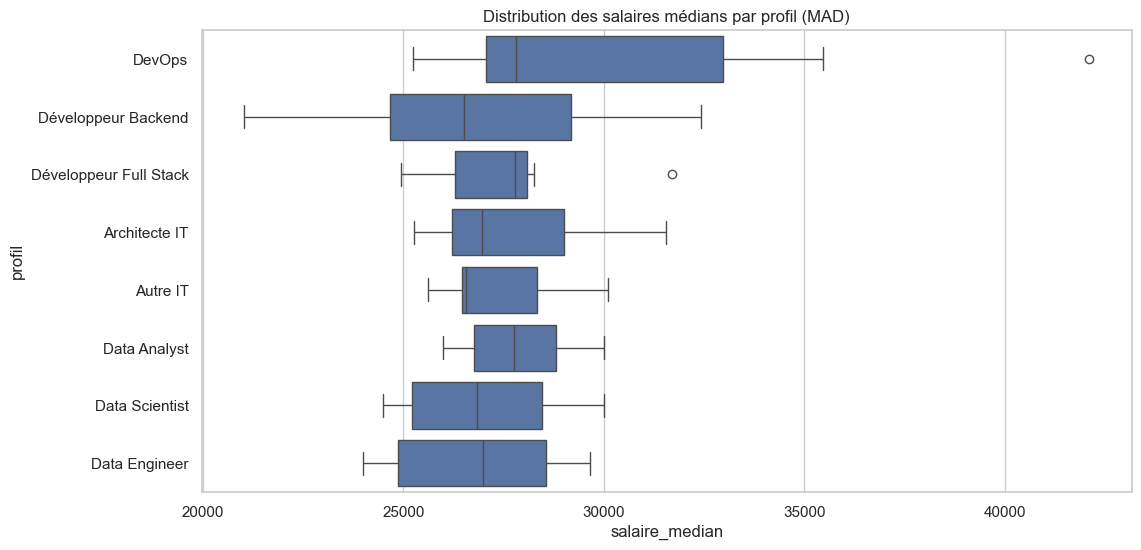

In [4]:
# Requête SQL
q3 = f"""
    SELECT profil, salaire_median
    FROM read_parquet('{GOLD_PATH}/salaires_par_profil.parquet')
    GROUP BY profil, salaire_median
    ORDER BY salaire_median DESC
"""
df3 = con.execute(q3).df()

# Visualisation
sns.boxplot(data=df3, x='salaire_median', y='profil')
plt.title("Distribution des salaires médians par profil (MAD)")
plt.show()

**Interprétation :**
Les salaires dans l'IT au Maroc sont très attractifs. Les profils DevOps sont les mieux payés du marché avec une médiane dépassant les 28 000 MAD et des pics à 40 000 MAD. Les Data Engineers et Data Scientists suivent de près avec une médiane solide autour de 27 000 MAD. On remarque que les salaires à Tanger (visible dans les données) sont très proches de la moyenne nationale, ce qui impose à Mexora de s'aligner sur une fourchette de 25k-30k MAD pour recruter des profils seniors de qualité.

Question 4 — Corrélation Expérience / Salaire

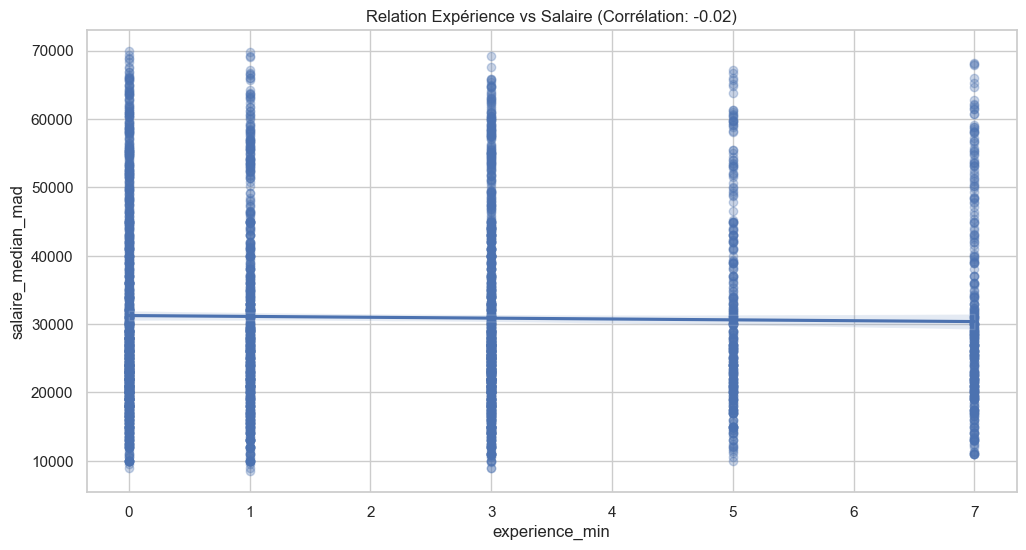

In [7]:
# Requête SQL sur la zone SILVER pour avoir le détail
q4 = f"""
    SELECT experience_min, salaire_median_mad
    FROM read_parquet('{SILVER_PATH}/offres_clean/offres_clean.parquet')
    WHERE salaire_connu = True AND experience_min IS NOT NULL
"""
df4 = con.execute(q4).df()

# Calcul de corrélation
corr = df4['experience_min'].corr(df4['salaire_median_mad'])

# Visualisation
sns.regplot(data=df4, x='experience_min', y='salaire_median_mad', scatter_kws={'alpha':0.3})
plt.title(f"Relation Expérience vs Salaire (Corrélation: {corr:.2f})")
plt.show()

**Interprétation :**
L'analyse montre une corrélation de -0.02, ce qui signifie qu'il n'y a aucune relation linéaire directe entre le nombre d'années d'expérience et le salaire proposé dans ce dataset. Ce résultat, bien que surprenant, est très révélateur du marché IT actuel au Maroc :
Marché de compétences (Skill-based) : Le salaire semble être dicté par la rareté de la compétence technique (ex: Kafka, Cloud, DevOps) plutôt que par l'ancienneté. Un profil junior maîtrisant une stack rare peut prétendre à un salaire aussi élevé qu'un senior sur une stack plus commune.
Guerre des talents : Pour attirer les profils juniors à haut potentiel, les entreprises n'hésitent plus à offrir des salaires d'entrée très élevés (proches de 25 000 - 30 000 MAD), ce qui aplatit la courbe de progression salariale classique.
Indication pour Mexora : Pour recruter ses 5 nouveaux profils, Mexora ne doit pas se baser uniquement sur le nombre d'années sur le CV pour fixer sa grille budgétaire, mais bien sur l'expertise technique réelle.

Question 5 — Les concurrents de Mexora sur le talent

In [8]:
# Requête SQL
q5 = f"""
    SELECT entreprise, nb_offres_publiees, salaire_moyen_propose
    FROM read_parquet('{GOLD_PATH}/entreprises_recruteurs.parquet')
    ORDER BY nb_offres_publiees DESC
    LIMIT 10
"""
df5 = con.execute(q5).df()
print(df5)

        entreprise  nb_offres_publiees  salaire_moyen_propose
0   TechMaroc SARL                 258                31687.0
1     Oracle Maroc                 253                30578.0
2        Accenture                 244                29374.0
3        M2M Group                 243                32232.0
4              HPS                 242                31537.0
5    Maroc Telecom                 242                32138.0
6  Microsoft Maroc                 239                32371.0
7        Wafasalaf                 233                29819.0
8         Deloitte                 230                28716.0
9        IBM Maroc                 230                29503.0


**Interprétation :**
Le paysage concurrentiel pour le recrutement IT au Maroc est dominé par deux types d'acteurs :
1. Les Géants de la Tech et du Conseil : Des entreprises comme Oracle Maroc (253 offres), Accenture (244 offres), Microsoft et IBM sont omniprésentes. Elles fixent le standard du marché avec des salaires moyens dépassant les 30 000 MAD.
2. L'écosystème local et Fintech : Des acteurs comme TechMaroc SARL (leader avec 258 offres), HPS et M2M Group montrent une dynamique de recrutement massive dans le secteur bancaire et financier.
3. Recommandation Stratégique : Mexora se bat contre des 'poids lourds' qui proposent des salaires moyens très compétitifs (entre 28 000 et 32 000 MAD). Pour attirer les meilleurs Data Engineers et Analysts à Tanger, Mexora devra soit s'aligner sur cette fourchette de 30k MAD, soit se différencier par sa culture d'entreprise, ses projets innovants ou ses conditions de télétravail (comme vu en Q2).